# Career-City Fit: Data Wrangling and EDA

This notebook downloads, cleans, merges, validates, and explores the 2020-2024 occupation–metro dataset.

Final output:

- `data/processed/career_city_fit_2020_2024.csv`
- `data/processed/career_city_fit_2020_2024.parquet`

## 1. Setup

In [1]:
%pip install -q polars pandas openpyxl requests matplotlib pyarrow


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from __future__ import annotations

import json
import os
import re
import zipfile
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import requests
from IPython.display import display

pl.Config.set_tbl_rows(12)
pl.Config.set_tbl_cols(16)
pl.Config.set_fmt_str_lengths(90)

PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
FIG_DIR = PROJECT_ROOT / "figures"

for path in [
    RAW_DIR / "bls",
    RAW_DIR / "acs",
    INTERIM_DIR,
    PROCESSED_DIR,
    FIG_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

USER_AGENT = "career-city-fit-notebook/2.0 (education project)"
SESSION = requests.Session()
SESSION.headers.update({"User-Agent": USER_AGENT})

In [3]:
YEARS = list(range(2020, 2025))

ACS_PRODUCT = "acs5"

CENSUS_API_KEY = os.getenv("CENSUS_API_KEY")

STANDARD_FULL_TIME_HOURS = 2080

FINAL_DATASET_CSV_PATH = PROCESSED_DIR / "career_city_fit_2020_2024.csv"
FINAL_DATASET_PARQUET_PATH = PROCESSED_DIR / "career_city_fit_2020_2024.parquet"
YEARLY_BUILD_SUMMARY_CSV_PATH = INTERIM_DIR / "yearly_build_summary.csv"

IMPORTANT_FINAL_COLUMNS = [
    "year",
    "cbsa_code",
    "bls_msa_name",
    "acs_area_name",
    "prim_state",
    "occ_code",
    "occ_title",
    "o_group",
    "tot_emp",
    "emp_prse",
    "jobs_1000",
    "loc_quotient",
    "h_mean",
    "a_mean",
    "h_median",
    "a_median",
    "wage_annual_mean",
    "wage_annual_median",
    "mean_wage_source",
    "median_wage_source",
    "median_gross_rent",
    "annual_rent",
    "median_household_income",
    "population",
    "rent_to_mean_wage_ratio",
    "rent_to_median_wage_ratio",
    "mean_wage_to_rent_ratio",
    "median_wage_to_rent_ratio",
    "annual_mean_wage_to_metro_income_ratio",
    "annual_median_wage_to_metro_income_ratio",
    "log_tot_emp",
    "low_employment_flag",
    "high_lq_flag",
    "has_valid_mean_affordability",
    "has_valid_median_affordability",
]

## 2. Helper Functions

In [4]:
def year_paths(year: int) -> dict[str, Path]:
    yy = str(year)[-2:]

    return {
        "bls_zip": RAW_DIR / "bls" / f"oesm{yy}ma.zip",
        "bls_extract_dir": RAW_DIR / "bls" / f"oesm{yy}ma_extracted",
        "bls_raw_csv": RAW_DIR / "bls" / f"oews_{year}_raw.csv",
        "acs_raw_json": RAW_DIR / "acs" / f"acs_{year}_{ACS_PRODUCT}_metro_raw.json",
        "acs_raw_csv": RAW_DIR / "acs" / f"acs_{year}_{ACS_PRODUCT}_metro_raw.csv",
        "acs_clean_csv": INTERIM_DIR / f"acs_{year}_metro_context.csv",
        "bls_clean_csv": INTERIM_DIR / f"oews_{year}_occ_metro.csv",
        "merged_csv": PROCESSED_DIR / f"occ_metro_{year}_merged.csv",
        "unmatched_acs_csv": INTERIM_DIR / f"acs_unmatched_to_bls_{year}.csv",
    }


def bls_oews_zip_url(year: int) -> str:
    yy = str(year)[-2:]
    return f"https://www.bls.gov/oes/special-requests/oesm{yy}ma.zip"


def acs_base_url(year: int) -> str:
    return f"https://api.census.gov/data/{year}/acs/{ACS_PRODUCT}"


def acs_params() -> dict:
    params = {
        "get": "NAME,B25064_001E,B19013_001E,B01003_001E",
        "for": "metropolitan statistical area/micropolitan statistical area:*",
    }

    if CENSUS_API_KEY:
        params["key"] = CENSUS_API_KEY

    return params


def download_file(
    url: str,
    destination: Path,
    overwrite: bool = False,
    chunk_size: int = 1024 * 1024,
) -> Path:
    destination.parent.mkdir(parents=True, exist_ok=True)

    if destination.exists() and not overwrite:
        print(f"Using existing file: {destination}")
        return destination

    print(f"Downloading: {url}")

    with SESSION.get(url, stream=True, timeout=180) as response:
        response.raise_for_status()

        with open(destination, "wb") as f:
            for chunk in response.iter_content(chunk_size=chunk_size):
                if chunk:
                    f.write(chunk)

    print(f"Saved: {destination} ({destination.stat().st_size / 1_000_000:.2f} MB)")
    return destination


def sanitize_column_name(name: str) -> str:
    name = str(name).strip().lower()
    name = re.sub(r"[%/]", " ", name)
    name = re.sub(r"[^a-z0-9]+", "_", name)
    name = re.sub(r"_+", "_", name).strip("_")
    return name


def sanitize_columns(columns: Iterable[str]) -> list[str]:
    return [sanitize_column_name(c) for c in columns]


def pick_first_existing(columns: list[str], candidates: list[str]) -> str | None:
    for candidate in candidates:
        if candidate in columns:
            return candidate
    return None


def ensure_columns(df: pl.DataFrame, columns: list[str]) -> pl.DataFrame:
    missing = [c for c in columns if c not in df.columns]

    if missing:
        df = df.with_columns([pl.lit(None).alias(c) for c in missing])

    return df


def to_numeric_expr(column_name: str, dtype: pl.DataType = pl.Float64) -> pl.Expr:
    return (
        pl.col(column_name)
        .cast(pl.Utf8)
        .str.replace_all(",", "")
        .str.replace_all(r"[^0-9.\-]", "")
        .replace("", None)
        .cast(dtype, strict=False)
        .alias(column_name)
    )


def remove_negative_sentinel_expr(column_name: str) -> pl.Expr:
    return (
        pl.when(pl.col(column_name) < 0)
        .then(None)
        .otherwise(pl.col(column_name))
        .alias(column_name)
    )


def print_shape(label: str, df: pl.DataFrame) -> None:
    print(f"{label}: {df.height:,} rows × {df.width:,} cols")


def display_pl(df: pl.DataFrame, rows: int = 8) -> None:
    display(df.head(rows).to_pandas())


def read_final_dataset() -> pl.DataFrame:
    df = pl.read_csv(FINAL_DATASET_CSV_PATH, infer_schema_length=5000)

    if "cbsa_code" in df.columns:
        df = df.with_columns(
            pl.col("cbsa_code").cast(pl.Utf8).str.zfill(5).alias("cbsa_code")
        )

    if "occ_code" in df.columns:
        df = df.with_columns(
            pl.col("occ_code").cast(pl.Utf8).alias("occ_code")
        )

    return df

In [5]:
def choose_bls_data_member(zf: zipfile.ZipFile) -> str:
    candidate_infos = []

    for info in zf.infolist():
        name = info.filename
        lower = name.lower()

        if lower.endswith("/"):
            continue

        if not lower.endswith((".xlsx", ".xls", ".csv", ".txt")):
            continue

        if any(
            bad in lower
            for bad in [
                "readme",
                "field_description",
                "field descriptions",
                "layout",
            ]
        ):
            continue

        score = info.file_size

        if "dl" in lower or "data" in lower:
            score += 1_000_000_000

        if lower.endswith((".xlsx", ".xls")):
            score += 100_000_000

        candidate_infos.append((score, info))

    if not candidate_infos:
        raise FileNotFoundError("No usable BLS data file found inside ZIP.")

    chosen_info = max(candidate_infos, key=lambda x: x[0])[1]
    return chosen_info.filename


def extract_bls_zip(year: int, overwrite: bool = False) -> Path:
    paths = year_paths(year)
    paths["bls_extract_dir"].mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(paths["bls_zip"], "r") as zf:
        member = choose_bls_data_member(zf)
        extracted_path = paths["bls_extract_dir"] / member

        if overwrite or not extracted_path.exists():
            print(f"Extracting BLS {year} file: {member}")
            zf.extract(member, path=paths["bls_extract_dir"])
        else:
            print(f"Using existing extracted BLS file: {extracted_path}")

    return extracted_path


def read_bls_raw_file_to_csv(year: int, overwrite: bool = False) -> Path:
    paths = year_paths(year)

    if paths["bls_raw_csv"].exists() and not overwrite:
        print(f"Using existing raw BLS CSV: {paths['bls_raw_csv']}")
        return paths["bls_raw_csv"]

    extracted_path = extract_bls_zip(year, overwrite=overwrite)
    suffix = extracted_path.suffix.lower()

    if suffix in {".xlsx", ".xls"}:
        raw_pd = pd.read_excel(extracted_path, sheet_name=0)
    elif suffix == ".csv":
        raw_pd = pd.read_csv(extracted_path)
    elif suffix == ".txt":
        raw_pd = pd.read_csv(extracted_path, sep=None, engine="python")
    else:
        raise ValueError(f"Unsupported BLS file type: {suffix}")

    raw_pd.to_csv(paths["bls_raw_csv"], index=False)

    print(f"Raw BLS {year} shape: {raw_pd.shape[0]:,} rows × {raw_pd.shape[1]:,} cols")
    print(f"Saved raw BLS CSV: {paths['bls_raw_csv']}")

    return paths["bls_raw_csv"]

## 3. Download Raw Source Data

In [6]:
def download_acs_year(year: int, overwrite: bool = False) -> Path:
    paths = year_paths(year)

    if paths["acs_raw_csv"].exists() and not overwrite:
        print(f"Using existing raw ACS CSV: {paths['acs_raw_csv']}")
        return paths["acs_raw_csv"]

    print(f"Requesting ACS {year} {ACS_PRODUCT} API data...")

    response = SESSION.get(
        acs_base_url(year),
        params=acs_params(),
        timeout=180,
    )
    response.raise_for_status()

    acs_json = response.json()

    with open(paths["acs_raw_json"], "w", encoding="utf-8") as f:
        json.dump(acs_json, f)

    acs_header = acs_json[0]
    acs_rows = acs_json[1:]

    acs_raw_pd = pd.DataFrame(acs_rows, columns=acs_header)
    acs_raw_pd.to_csv(paths["acs_raw_csv"], index=False)

    print(f"Saved ACS raw JSON: {paths['acs_raw_json']}")
    print(f"Saved ACS raw CSV:  {paths['acs_raw_csv']}")

    return paths["acs_raw_csv"]

## 3. Download Raw Source Data

In [7]:
for year in YEARS:
    print("=" * 90)
    print(f"Downloading source files for {year}")
    print("=" * 90)

    paths = year_paths(year)

    download_file(bls_oews_zip_url(year), paths["bls_zip"])
    download_acs_year(year)

print("Finished downloading raw files.")

Downloading: https://www.bls.gov/oes/special-requests/oesm20ma.zip
Saved: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/raw/bls/oesm20ma.zip (36.37 MB)
Requesting ACS 2020 acs5 API data...
Saved ACS raw JSON: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/raw/acs/acs_2020_acs5_metro_raw.json
Saved ACS raw CSV:  /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/raw/acs/acs_2020_acs5_metro_raw.csv
Downloading: https://www.bls.gov/oes/special-requests/oesm21ma.zip
Saved: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/raw/bls/oesm21ma.zip (38.87 MB)
Requesting ACS 2021 acs5 API data...
Saved ACS raw JSON: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/raw/acs/acs_2021_acs5_metro_raw.json
Saved ACS raw CSV:  /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/raw/acs/acs_2021_acs5_metro_raw.csv
Downloading: https://www.bls.gov/oes/special-requests/oesm22ma.zip
Saved: /Users/omarelnesr/Desktop/Classes/CIS 2450

## 4. Clean ACS Metro Context Data

In [8]:
def clean_acs_year(year: int) -> pl.DataFrame:
    paths = year_paths(year)

    acs_raw = pl.read_csv(paths["acs_raw_csv"], infer_schema_length=0)
    acs_raw.columns = sanitize_columns(acs_raw.columns)

    geo_code_col = pick_first_existing(
        acs_raw.columns,
        [
            "metropolitan_statistical_area_micropolitan_statistical_area",
            "metropolitan_statistical_area",
            "micropolitan_statistical_area",
        ],
    )

    if geo_code_col is None:
        raise KeyError(
            "Could not identify ACS CBSA geography-code column. "
            f"Available columns: {acs_raw.columns}"
        )

    acs_clean = (
        acs_raw
        .rename({
            "name": "acs_area_name",
            geo_code_col: "cbsa_code",
            "b25064_001e": "median_gross_rent",
            "b19013_001e": "median_household_income",
            "b01003_001e": "population",
        })
        .with_columns([
            pl.lit(year).alias("year"),
            pl.col("cbsa_code").cast(pl.Utf8).str.zfill(5).alias("cbsa_code"),
            to_numeric_expr("median_gross_rent", pl.Int64),
            to_numeric_expr("median_household_income", pl.Int64),
            to_numeric_expr("population", pl.Int64),
        ])
        .with_columns([
            remove_negative_sentinel_expr("median_gross_rent"),
            remove_negative_sentinel_expr("median_household_income"),
            remove_negative_sentinel_expr("population"),
        ])
        .with_columns([
            (pl.col("median_gross_rent") * 12).alias("annual_rent"),
        ])
        .select([
            "year",
            "cbsa_code",
            "acs_area_name",
            "median_gross_rent",
            "annual_rent",
            "median_household_income",
            "population",
        ])
        .unique(subset=["year", "cbsa_code"])
        .sort("cbsa_code")
    )

    acs_clean.write_csv(paths["acs_clean_csv"])

    print_shape(f"ACS clean metro context {year}", acs_clean)
    print(f"Saved: {paths['acs_clean_csv']}")

    return acs_clean

## 5. Clean BLS OEWS Occupation–Metro Data

In [9]:
def clean_bls_year(year: int) -> pl.DataFrame:
    paths = year_paths(year)

    read_bls_raw_file_to_csv(year)

    bls_raw = pl.read_csv(
        paths["bls_raw_csv"],
        infer_schema_length=5000,
        ignore_errors=True,
    )
    bls_raw.columns = sanitize_columns(bls_raw.columns)

    expected_bls_cols = [
        "area",
        "area_title",
        "area_type",
        "prim_state",
        "naics",
        "naics_title",
        "i_group",
        "own_code",
        "occ_code",
        "occ_title",
        "o_group",
        "tot_emp",
        "emp_prse",
        "jobs_1000",
        "loc_quotient",
        "pct_total",
        "pct_rpt",
        "h_mean",
        "a_mean",
        "mean_prse",
        "h_pct10",
        "h_pct25",
        "h_median",
        "h_pct75",
        "h_pct90",
        "a_pct10",
        "a_pct25",
        "a_median",
        "a_pct75",
        "a_pct90",
        "annual",
        "hourly",
    ]

    required_cols = ["area", "area_title", "occ_code", "occ_title", "o_group"]
    missing_required = [c for c in required_cols if c not in bls_raw.columns]

    if missing_required:
        raise KeyError(
            f"BLS {year} raw file is missing required columns: {missing_required}. "
            f"Available columns: {bls_raw.columns}"
        )

    bls_raw = ensure_columns(bls_raw, expected_bls_cols)

    text_cols = [
        "area",
        "area_title",
        "area_type",
        "prim_state",
        "naics",
        "naics_title",
        "i_group",
        "own_code",
        "occ_code",
        "occ_title",
        "o_group",
        "annual",
        "hourly",
    ]

    numeric_cols = [
        "tot_emp",
        "emp_prse",
        "jobs_1000",
        "loc_quotient",
        "pct_total",
        "pct_rpt",
        "h_mean",
        "a_mean",
        "mean_prse",
        "h_pct10",
        "h_pct25",
        "h_median",
        "h_pct75",
        "h_pct90",
        "a_pct10",
        "a_pct25",
        "a_median",
        "a_pct75",
        "a_pct90",
    ]

    bls_clean = (
        bls_raw
        .select(expected_bls_cols)
        .with_columns([
            pl.lit(year).alias("year"),
            *[
                pl.col(c).cast(pl.Utf8).str.strip_chars().alias(c)
                for c in text_cols
            ],
        ])
        .with_columns([
            pl.col("i_group").str.to_lowercase().alias("i_group"),
            pl.col("o_group").str.to_lowercase().alias("o_group"),
            pl.col("naics_title").str.to_lowercase().alias("naics_title"),
        ])
        .with_columns([
            *[to_numeric_expr(c, pl.Float64) for c in numeric_cols],
        ])
        .with_columns([
            pl.col("area").str.extract(r"(\d{5})", 1).str.zfill(5).alias("cbsa_code"),
        ])
        .filter(
            pl.col("area_title").is_not_null()
            & pl.col("occ_code").is_not_null()
            & pl.col("occ_title").is_not_null()
            & pl.col("cbsa_code").is_not_null()
        )
        .with_columns([
            pl.col("cbsa_code").cast(pl.Int64, strict=False).alias("cbsa_int"),
        ])
        .filter(pl.col("cbsa_int").is_not_null() & (pl.col("cbsa_int") < 100000))
        .filter(
            ~pl.col("area_title")
            .str.to_lowercase()
            .str.contains("nonmetropolitan")
            .fill_null(False)
        )
    )

    detail_occ_filter = (
        pl.col("o_group").str.contains("detail").fill_null(False)
        | (
            pl.col("occ_code").str.contains(r"^\d{2}-\d{4}$").fill_null(False)
            & ~pl.col("occ_code").str.ends_with("0000").fill_null(False)
        )
    )

    bls_clean = bls_clean.filter(detail_occ_filter)

    cross_industry_filter = (
        pl.col("i_group").str.contains("cross").fill_null(False)
        | pl.col("naics_title").str.contains("cross").fill_null(False)
        | (pl.col("naics") == "000000")
    )

    cross_industry_count = bls_clean.filter(cross_industry_filter).height

    if cross_industry_count > 0:
        bls_clean = bls_clean.filter(cross_industry_filter)
        print(f"BLS {year}: kept cross-industry rows only: {cross_industry_count:,}")
    else:
        print(f"BLS {year}: no cross-industry marker found; keeping detailed occupation rows.")

    bls_clean = (
        bls_clean
        .with_columns([
            pl.col("area_title").alias("bls_msa_name"),

            pl.when(pl.col("a_mean").is_not_null() & (pl.col("a_mean") > 0))
            .then(pl.col("a_mean"))
            .when(pl.col("h_mean").is_not_null() & (pl.col("h_mean") > 0))
            .then(pl.col("h_mean") * STANDARD_FULL_TIME_HOURS)
            .otherwise(None)
            .alias("wage_annual_mean"),

            pl.when(pl.col("a_median").is_not_null() & (pl.col("a_median") > 0))
            .then(pl.col("a_median"))
            .when(pl.col("h_median").is_not_null() & (pl.col("h_median") > 0))
            .then(pl.col("h_median") * STANDARD_FULL_TIME_HOURS)
            .otherwise(None)
            .alias("wage_annual_median"),

            pl.when(pl.col("a_mean").is_not_null() & (pl.col("a_mean") > 0))
            .then(pl.lit("reported_annual"))
            .when(pl.col("h_mean").is_not_null() & (pl.col("h_mean") > 0))
            .then(pl.lit("estimated_from_hourly"))
            .otherwise(None)
            .alias("mean_wage_source"),

            pl.when(pl.col("a_median").is_not_null() & (pl.col("a_median") > 0))
            .then(pl.lit("reported_annual"))
            .when(pl.col("h_median").is_not_null() & (pl.col("h_median") > 0))
            .then(pl.lit("estimated_from_hourly"))
            .otherwise(None)
            .alias("median_wage_source"),
        ])
        .select([
            "year",
            "cbsa_code",
            "bls_msa_name",
            "area_title",
            "prim_state",
            "occ_code",
            "occ_title",
            "o_group",
            "tot_emp",
            "emp_prse",
            "jobs_1000",
            "loc_quotient",
            "h_mean",
            "a_mean",
            "h_median",
            "a_median",
            "wage_annual_mean",
            "wage_annual_median",
            "mean_wage_source",
            "median_wage_source",
        ])
        .sort(["cbsa_code", "occ_code"])
    )

    bls_clean.write_csv(paths["bls_clean_csv"])

    print_shape(f"BLS clean occupation × metro rows {year}", bls_clean)
    print(f"Saved: {paths['bls_clean_csv']}")

    return bls_clean

## 6. Merge Occupation–Metro Data with Metro Context Data

In [10]:
def merge_bls_acs_year(year: int) -> pl.DataFrame:
    paths = year_paths(year)

    acs_clean = clean_acs_year(year)
    bls_clean = clean_bls_year(year)

    merged = (
        bls_clean
        .join(
            acs_clean.select([
                "year",
                "cbsa_code",
                "acs_area_name",
                "median_gross_rent",
                "annual_rent",
                "median_household_income",
                "population",
            ]),
            on=["year", "cbsa_code"],
            how="left",
        )
        .with_columns([
            pl.when(
                pl.col("annual_rent").is_not_null()
                & pl.col("wage_annual_mean").is_not_null()
                & (pl.col("wage_annual_mean") > 0)
            )
            .then(pl.col("annual_rent") / pl.col("wage_annual_mean"))
            .otherwise(None)
            .alias("rent_to_mean_wage_ratio"),

            pl.when(
                pl.col("annual_rent").is_not_null()
                & pl.col("wage_annual_median").is_not_null()
                & (pl.col("wage_annual_median") > 0)
            )
            .then(pl.col("annual_rent") / pl.col("wage_annual_median"))
            .otherwise(None)
            .alias("rent_to_median_wage_ratio"),

            pl.when(
                pl.col("annual_rent").is_not_null()
                & (pl.col("annual_rent") > 0)
                & pl.col("wage_annual_mean").is_not_null()
            )
            .then(pl.col("wage_annual_mean") / pl.col("annual_rent"))
            .otherwise(None)
            .alias("mean_wage_to_rent_ratio"),

            pl.when(
                pl.col("annual_rent").is_not_null()
                & (pl.col("annual_rent") > 0)
                & pl.col("wage_annual_median").is_not_null()
            )
            .then(pl.col("wage_annual_median") / pl.col("annual_rent"))
            .otherwise(None)
            .alias("median_wage_to_rent_ratio"),

            pl.when(
                pl.col("median_household_income").is_not_null()
                & (pl.col("median_household_income") > 0)
                & pl.col("wage_annual_mean").is_not_null()
            )
            .then(pl.col("wage_annual_mean") / pl.col("median_household_income"))
            .otherwise(None)
            .alias("annual_mean_wage_to_metro_income_ratio"),

            pl.when(
                pl.col("median_household_income").is_not_null()
                & (pl.col("median_household_income") > 0)
                & pl.col("wage_annual_median").is_not_null()
            )
            .then(pl.col("wage_annual_median") / pl.col("median_household_income"))
            .otherwise(None)
            .alias("annual_median_wage_to_metro_income_ratio"),

            pl.when(pl.col("tot_emp").is_not_null() & (pl.col("tot_emp") > 0))
            .then(pl.col("tot_emp").log())
            .otherwise(None)
            .alias("log_tot_emp"),

            pl.when(pl.col("tot_emp").is_not_null())
            .then(pl.col("tot_emp") < 100)
            .otherwise(None)
            .alias("low_employment_flag"),

            pl.when(pl.col("loc_quotient").is_not_null())
            .then(pl.col("loc_quotient") > 1.25)
            .otherwise(None)
            .alias("high_lq_flag"),
        ])
        .with_columns([
            pl.col("rent_to_mean_wage_ratio")
            .is_not_null()
            .alias("has_valid_mean_affordability"),

            pl.col("rent_to_median_wage_ratio")
            .is_not_null()
            .alias("has_valid_median_affordability"),

            pl.col("rent_to_mean_wage_ratio")
            .alias("rent_to_annual_mean_wage_ratio"),

            pl.col("rent_to_median_wage_ratio")
            .alias("rent_to_annual_median_wage_ratio"),
        ])
        .sort(["year", "cbsa_code", "occ_code"])
    )

    merged.write_csv(paths["merged_csv"])

    unmatched_acs = (
        merged
        .filter(pl.col("annual_rent").is_null())
        .select(["year", "cbsa_code", "bls_msa_name"])
        .unique()
        .sort(["year", "cbsa_code"])
    )

    unmatched_acs.write_csv(paths["unmatched_acs_csv"])

    print_shape(f"Merged occupation × metro dataset {year}", merged)
    print(f"Saved merged CSV: {paths['merged_csv']}")
    print(f"Saved unmatched ACS diagnostics: {paths['unmatched_acs_csv']}")

    return merged

## 7. Build Final 2020-2024 Processed Dataset

In [11]:
year_frames = []
build_summary_rows = []

for year in YEARS:
    print("\n" + "=" * 90)
    print(f"Building merged dataset for {year}")
    print("=" * 90)

    merged_year = merge_bls_acs_year(year)
    year_frames.append(merged_year)

    build_summary_rows.append({
        "year": year,
        "rows": merged_year.height,
        "columns": merged_year.width,
        "metros": merged_year.select(pl.col("cbsa_code").n_unique()).item(),
        "occupations": merged_year.select(pl.col("occ_code").n_unique()).item(),
        "missing_annual_rent_pct": merged_year.select(
            (pl.col("annual_rent").is_null().cast(pl.Float64).mean() * 100)
        ).item(),
        "missing_mean_wage_pct": merged_year.select(
            (pl.col("wage_annual_mean").is_null().cast(pl.Float64).mean() * 100)
        ).item(),
        "missing_median_wage_pct": merged_year.select(
            (pl.col("wage_annual_median").is_null().cast(pl.Float64).mean() * 100)
        ).item(),
    })

df_all = (
    pl.concat(year_frames, how="diagonal_relaxed")
    .sort(["year", "cbsa_code", "occ_code"])
)

ordered_cols = [c for c in IMPORTANT_FINAL_COLUMNS if c in df_all.columns]
remaining_cols = [c for c in df_all.columns if c not in ordered_cols]

df_all = df_all.select(ordered_cols + remaining_cols)

df_all.write_csv(FINAL_DATASET_CSV_PATH)
df_all.write_parquet(FINAL_DATASET_PARQUET_PATH)

build_summary = pl.DataFrame(build_summary_rows).sort("year")
build_summary.write_csv(YEARLY_BUILD_SUMMARY_CSV_PATH)

print_shape("Final 2020-2024 occupation × metro dataset", df_all)
print(f"Saved final CSV:     {FINAL_DATASET_CSV_PATH}")
print(f"Saved final Parquet: {FINAL_DATASET_PARQUET_PATH}")
print(f"Saved build summary: {YEARLY_BUILD_SUMMARY_CSV_PATH}")

display(build_summary.to_pandas())
display(df_all.head(20).to_pandas())


Building merged dataset for 2020
ACS clean metro context 2020: 939 rows × 7 cols
Saved: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/interim/acs_2020_metro_context.csv
Extracting BLS 2020 file: oesm20ma/MSA_M2020_dl.xlsx
Raw BLS 2020 shape: 140,051 rows × 31 cols
Saved raw BLS CSV: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/raw/bls/oews_2020_raw.csv
BLS 2020: kept cross-industry rows only: 131,010
BLS clean occupation × metro rows 2020: 131,010 rows × 20 cols
Saved: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/interim/oews_2020_occ_metro.csv
Merged occupation × metro dataset 2020: 131,010 rows × 38 cols
Saved merged CSV: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/processed/occ_metro_2020_merged.csv
Saved unmatched ACS diagnostics: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/interim/acs_unmatched_to_bls_2020.csv

Building merged dataset for 2021
ACS clean metro context 2021: 939 rows × 7 cols
Save

,year,rows,columns,metros,occupations,missing_annual_rent_pct,missing_mean_wage_pct,missing_median_wage_pct
0,2020,131010,38,396,785,6.283490,1.976185,2.644073
1,2021,138116,38,396,826,6.225202,0.850734,1.673955
2,2022,139124,38,396,828,6.135534,1.127771,1.536759
3,2023,140518,38,396,826,7.248182,1.014105,1.586274
4,2024,141164,38,393,823,0.000000,1.037800,1.666147


,year,cbsa_code,bls_msa_name,acs_area_name,prim_state,occ_code,occ_title,o_group,tot_emp,emp_prse,...,annual_mean_wage_to_metro_income_ratio,annual_median_wage_to_metro_income_ratio,log_tot_emp,low_employment_flag,high_lq_flag,has_valid_mean_affordability,has_valid_median_affordability,area_title,rent_to_annual_mean_wage_ratio,rent_to_annual_median_wage_ratio
0,2020,10180,"Abilene, TX","Abilene, TX Metro Area",TX,11-1021,General and Operations Managers,detailed,1320.0,7.4,...,1.531072,1.249613,7.185387,False,False,True,True,"Abilene, TX",0.129730,0.158950
1,2020,10180,"Abilene, TX","Abilene, TX Metro Area",TX,11-2022,Sales Managers,detailed,90.0,18.5,...,2.206099,1.986984,4.499810,True,False,True,True,"Abilene, TX",0.090035,0.099963
2,2020,10180,"Abilene, TX","Abilene, TX Metro Area",TX,11-2030,Public Relations and Fundraising Managers,detailed,40.0,31.5,...,1.741619,1.374118,3.688879,True,False,True,True,"Abilene, TX",0.114046,0.144548
3,2020,10180,"Abilene, TX","Abilene, TX Metro Area",TX,11-3010,Administrative Services and Facilities Managers,detailed,140.0,12.3,...,1.432816,1.329274,4.941642,False,False,True,True,"Abilene, TX",0.138626,0.149424
4,2020,10180,"Abilene, TX","Abilene, TX Metro Area",TX,11-3021,Computer and Information Systems Managers,detailed,70.0,30.2,...,2.242923,2.133912,4.248495,True,False,True,True,"Abilene, TX",0.088557,0.093080
5,2020,10180,"Abilene, TX","Abilene, TX Metro Area",TX,11-3031,Financial Managers,detailed,120.0,8.8,...,2.179849,1.751463,4.787492,False,False,True,True,"Abilene, TX",0.091119,0.113405
6,2020,10180,"Abilene, TX","Abilene, TX Metro Area",TX,11-3051,Industrial Production Managers,detailed,50.0,22.3,...,2.072297,1.798859,3.912023,True,False,True,True,"Abilene, TX",0.095848,0.110418
7,2020,10180,"Abilene, TX","Abilene, TX Metro Area",TX,11-3071,"Transportation, Storage, and Distribution Mana...",detailed,60.0,18.6,...,1.550030,1.502634,4.094345,True,False,True,True,"Abilene, TX",0.128143,0.132185
8,2020,10180,"Abilene, TX","Abilene, TX Metro Area",TX,11-3121,Human Resources Managers,detailed,60.0,45.1,...,1.189274,0.887580,4.094345,True,False,True,True,"Abilene, TX",0.167014,0.223783
9,2020,10180,"Abilene, TX","Abilene, TX Metro Area",TX,11-9021,Construction Managers,detailed,160.0,14.2,...,1.402738,1.164300,5.075174,False,False,True,True,"Abilene, TX",0.141598,0.170597


## 8. Data Quality Diagnostics

In [12]:
df_all = read_final_dataset()

print_shape("Final dataset loaded for diagnostics", df_all)

coverage_by_year = (
    df_all
    .group_by("year")
    .agg([
        pl.len().alias("n_rows"),
        pl.col("cbsa_code").n_unique().alias("n_metros"),
        pl.col("occ_code").n_unique().alias("n_occupations"),

        (pl.col("annual_rent").is_null().cast(pl.Float64).mean() * 100)
        .round(2)
        .alias("pct_missing_annual_rent"),

        (pl.col("wage_annual_mean").is_null().cast(pl.Float64).mean() * 100)
        .round(2)
        .alias("pct_missing_mean_wage"),

        (pl.col("wage_annual_median").is_null().cast(pl.Float64).mean() * 100)
        .round(2)
        .alias("pct_missing_median_wage"),

        (pl.col("rent_to_mean_wage_ratio").is_null().cast(pl.Float64).mean() * 100)
        .round(2)
        .alias("pct_missing_mean_rent_burden"),

        (pl.col("rent_to_median_wage_ratio").is_null().cast(pl.Float64).mean() * 100)
        .round(2)
        .alias("pct_missing_median_rent_burden"),
    ])
    .sort("year")
)

display(coverage_by_year.to_pandas())

latest_year = df_all.select(pl.col("year").max()).item()
latest = df_all.filter(pl.col("year") == latest_year)

print(f"Latest year available: {latest_year}")

Final dataset loaded for diagnostics: 689,932 rows × 38 cols


,year,n_rows,n_metros,n_occupations,pct_missing_annual_rent,pct_missing_mean_wage,pct_missing_median_wage,pct_missing_mean_rent_burden,pct_missing_median_rent_burden
0,2020,131010,396,785,6.28,1.98,2.64,8.12,8.74
1,2021,138116,396,826,6.23,0.85,1.67,7.01,7.76
2,2022,139124,396,828,6.14,1.13,1.54,7.17,7.55
3,2023,140518,396,826,7.25,1.01,1.59,8.19,8.71
4,2024,141164,393,823,0.00,1.04,1.67,1.04,1.67


Latest year available: 2024


In [13]:
print("Top metros by number of occupation rows in latest year:")
display(
    latest
    .group_by("bls_msa_name")
    .agg(pl.len().alias("n_rows"))
    .sort("n_rows", descending=True)
    .head(15)
    .to_pandas()
)

print("Bottom metros by number of occupation rows in latest year:")
display(
    latest
    .group_by("bls_msa_name")
    .agg(pl.len().alias("n_rows"))
    .sort("n_rows")
    .head(15)
    .to_pandas()
)

print("Top occupations by total employment in latest year:")
display(
    latest
    .filter(pl.col("tot_emp").is_not_null())
    .group_by("occ_title")
    .agg(pl.sum("tot_emp").alias("total_emp"))
    .sort("total_emp", descending=True)
    .head(15)
    .to_pandas()
)

print("Top occupations by annual mean wage in latest year:")
display(
    latest
    .filter(pl.col("wage_annual_mean").is_not_null())
    .group_by("occ_title")
    .agg(pl.mean("wage_annual_mean").alias("avg_annual_mean_wage"))
    .sort("avg_annual_mean_wage", descending=True)
    .head(15)
    .to_pandas()
)

print("Bottom occupations by annual mean wage in latest year:")
display(
    latest
    .filter(pl.col("wage_annual_mean").is_not_null())
    .group_by("occ_title")
    .agg(pl.mean("wage_annual_mean").alias("avg_annual_mean_wage"))
    .sort("avg_annual_mean_wage")
    .head(15)
    .to_pandas()
)

Top metros by number of occupation rows in latest year:


,bls_msa_name,n_rows
0,"New York-Newark-Jersey City, NY-NJ",771
1,"Los Angeles-Long Beach-Anaheim, CA",755
2,"Philadelphia-Camden-Wilmington, PA-NJ-DE-MD",741
3,"Chicago-Naperville-Elgin, IL-IN",723
4,"Washington-Arlington-Alexandria, DC-VA-MD-WV",721
5,"Dallas-Fort Worth-Arlington, TX",721
6,"Seattle-Tacoma-Bellevue, WA",710
7,"Boston-Cambridge-Newton, MA-NH",704
8,"San Francisco-Oakland-Fremont, CA",702
9,"Miami-Fort Lauderdale-West Palm Beach, FL",700


Bottom metros by number of occupation rows in latest year:


,bls_msa_name,n_rows
0,"Guayama, PR",66
1,"Eagle Pass, TX",83
2,"Hinesville, GA",120
3,"Enid, OK",138
4,"Sebring, FL",144
5,"Kokomo, IN",151
6,"Lewiston, ID-WA",153
7,"Minot, ND",153
8,"Gadsden, AL",155
9,"Arecibo, PR",156


Top occupations by total employment in latest year:


,occ_title,total_emp
0,Home Health and Personal Care Aides,3581940.0
1,Retail Salespersons,3353990.0
2,Fast Food and Counter Workers,3343720.0
3,General and Operations Managers,3005350.0
4,Registered Nurses,2922860.0
5,Cashiers,2668090.0
6,"Laborers and Freight, Stock, and Material Move...",2588150.0
7,Stockers and Order Fillers,2420140.0
8,Customer Service Representatives,2324610.0
9,"Office Clerks, General",2123710.0


Top occupations by annual mean wage in latest year:


,occ_title,avg_annual_mean_wage
0,Cardiologists,410583.181818
1,"Surgeons, All Other",379346.206897
2,"Orthopedic Surgeons, Except Pediatric",358699.642857
3,Radiologists,352785.000000
4,Dermatologists,352500.555556
5,Anesthesiologists,341268.571429
6,Pediatric Surgeons,329020.000000
7,Emergency Medicine Physicians,312775.000000
8,Neurologists,306167.894737
9,Oral and Maxillofacial Surgeons,305016.666667


Bottom occupations by annual mean wage in latest year:


,occ_title,avg_annual_mean_wage
0,Amusement and Recreation Attendants,28990.189702
1,Shampooers,29086.000000
2,Fast Food and Counter Workers,29760.788804
3,"Hosts and Hostesses, Restaurant, Lounge, and C...",29967.169312
4,"Ushers, Lobby Attendants, and Ticket Takers",30003.650794
5,"Cooks, Fast Food",30072.330097
6,Dishwashers,30300.488432
7,Cashiers,30384.274809
8,Dining Room and Cafeteria Attendants and Barte...,30912.101064
9,Childcare Workers,31034.557292


## 9. Exploratory Data Analysis

In [14]:
df_all = read_final_dataset()

EDA_YEAR = df_all.select(pl.col("year").max()).item()

wage_col = "wage_annual_median"
ratio_col = "rent_to_median_wage_ratio"

eda = (
    df_all
    .filter(pl.col("year") == EDA_YEAR)
    .filter(pl.col("annual_rent").is_not_null())
    .filter(pl.col(wage_col).is_not_null())
    .filter(pl.col(ratio_col).is_not_null())
)

print(f"EDA year: {EDA_YEAR}")
print(f"Using wage column: {wage_col}")
print(f"Using rent-burden ratio: {ratio_col}")
print_shape("EDA dataset", eda)

eda_pd = (
    eda
    .select([
        "year",
        "cbsa_code",
        "bls_msa_name",
        "occ_code",
        "occ_title",
        "annual_rent",
        wage_col,
        ratio_col,
        "tot_emp",
        "jobs_1000",
        "loc_quotient",
    ])
    .to_pandas()
)

display(eda_pd.head())

EDA year: 2024
Using wage column: wage_annual_median
Using rent-burden ratio: rent_to_median_wage_ratio
EDA dataset: 138,812 rows × 38 cols


,year,cbsa_code,bls_msa_name,occ_code,occ_title,annual_rent,wage_annual_median,rent_to_median_wage_ratio,tot_emp,jobs_1000,loc_quotient
0,2024,10180,"Abilene, TX",11-1011,Chief Executives,13692,177520.0,0.077129,50.0,0.674,0.49
1,2024,10180,"Abilene, TX",11-1021,General and Operations Managers,13692,77340.0,0.177036,2240.0,30.253,1.30
2,2024,10180,"Abilene, TX",11-2021,Marketing Managers,13692,104030.0,0.131616,140.0,1.942,0.78
3,2024,10180,"Abilene, TX",11-2022,Sales Managers,13692,118610.0,0.115437,310.0,4.175,1.07
4,2024,10180,"Abilene, TX",11-2032,Public Relations Managers,13692,78830.0,0.173690,50.0,0.622,1.26


### 9.1 Row Coverage by Year

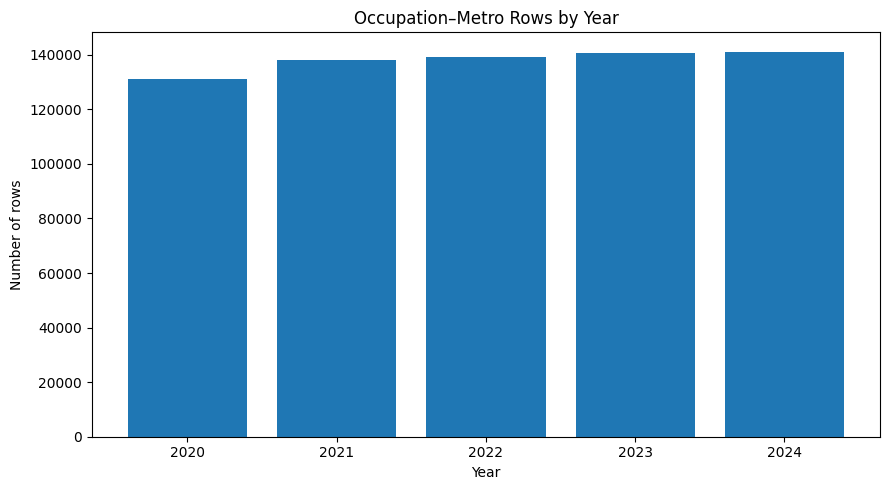

In [15]:
coverage_plot_pd = (
    df_all
    .group_by("year")
    .agg(pl.len().alias("n_rows"))
    .sort("year")
    .to_pandas()
)

plt.figure(figsize=(9, 5))
plt.bar(coverage_plot_pd["year"].astype(str), coverage_plot_pd["n_rows"])
plt.title("Occupation–Metro Rows by Year")
plt.xlabel("Year")
plt.ylabel("Number of rows")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_rows_by_year.png", dpi=150)
plt.show()

### 9.2 Annual Wage Distribution

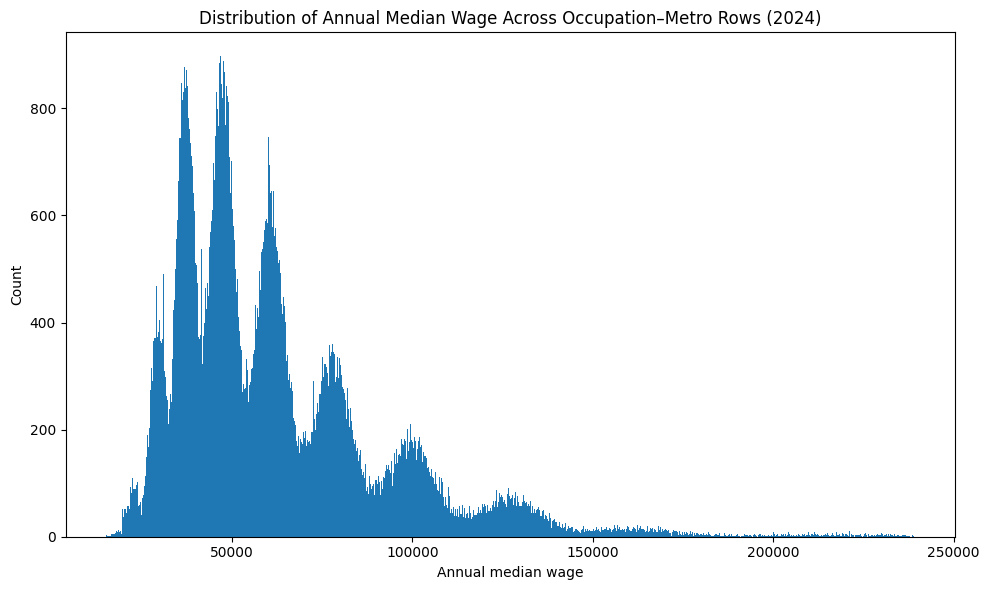

In [17]:
plot_df = eda_pd.dropna(subset=[wage_col]).copy()

plt.figure(figsize=(10, 6))
plt.hist(plot_df[wage_col], bins=1000)
plt.title(f"Distribution of Annual Median Wage Across Occupation–Metro Rows ({EDA_YEAR})")
plt.xlabel("Annual median wage")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_wage_distribution.png", dpi=150)
plt.show()

### 9.3 Annual Rent vs. Annual Wage

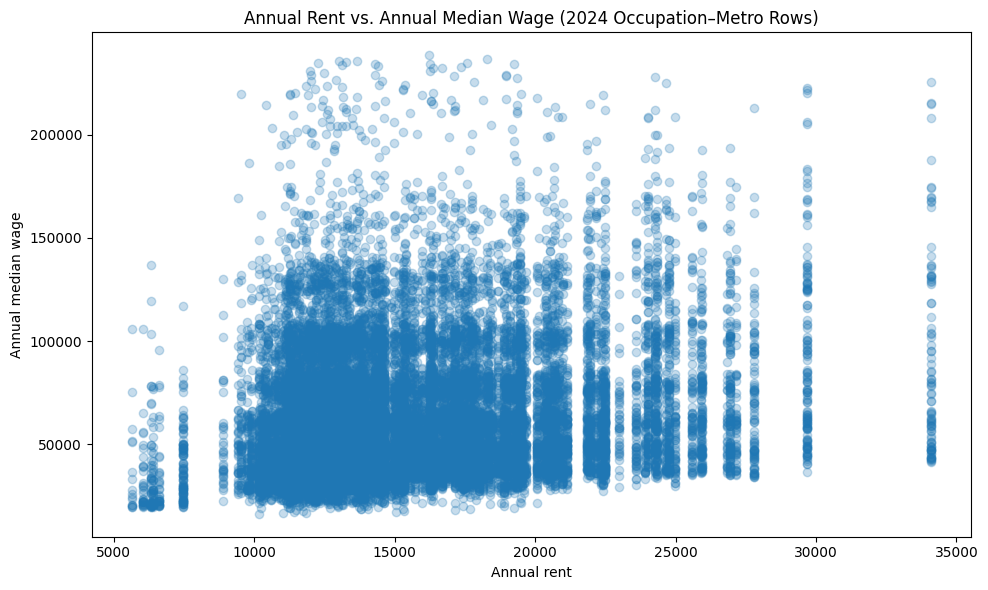

In [18]:
plot_df = eda_pd.dropna(subset=["annual_rent", wage_col]).copy()

if len(plot_df) > 25000:
    plot_df = plot_df.sample(25000, random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(plot_df["annual_rent"], plot_df[wage_col], alpha=0.25)
plt.title(f"Annual Rent vs. Annual Median Wage ({EDA_YEAR} Occupation–Metro Rows)")
plt.xlabel("Annual rent")
plt.ylabel("Annual median wage")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_rent_vs_wage_scatter.png", dpi=150)
plt.show()

### 9.4 Selected Occupation for Metro-Level Comparison

In [19]:
candidate_keywords = [
    "software developers",
    "registered nurses",
    "accountants",
    "data scientists",
    "financial analysts",
]

selected_occ = None
all_occ_titles = eda.select("occ_title").drop_nulls().unique().to_series().to_list()

for keyword in candidate_keywords:
    matches = [title for title in all_occ_titles if keyword in str(title).lower()]
    if matches:
        selected_occ = matches[0]
        break

if selected_occ is None:
    selected_occ = (
        eda
        .filter(pl.col("tot_emp").is_not_null())
        .group_by("occ_title")
        .agg(pl.sum("tot_emp").alias("total_emp"))
        .sort("total_emp", descending=True)
        .select("occ_title")
        .item()
    )

print("Selected occupation for metro-level comparison:")
print(selected_occ)

Selected occupation for metro-level comparison:
Software Developers


### 9.5 Top Metros for Selected Occupation by Rent Burden

,bls_msa_name,wage_annual_median,annual_rent,rent_to_median_wage_ratio,tot_emp,loc_quotient
0,"Aguadilla, PR",77370.0,6336,0.081892,120.0,0.23
1,"Hickory-Lenoir-Morganton, NC",121590.0,10428,0.085764,360.0,0.21
2,"Binghamton, NY",129600.0,11268,0.086944,1130.0,1.10
3,"Kingsport-Bristol, TN-VA",114540.0,10188,0.088947,440.0,0.35
4,"Johnstown, PA",97160.0,8868,0.091272,110.0,0.22
5,"Youngstown-Warren, OH",101870.0,9540,0.093649,270.0,0.16
6,"Ames, IA",127040.0,12000,0.094458,440.0,0.73
7,"Decatur, AL",105830.0,10164,0.096041,140.0,0.23
8,"Yuma, AZ",123840.0,11916,0.096221,200.0,0.26
9,"Winston-Salem, NC",125140.0,12192,0.097427,1270.0,0.43


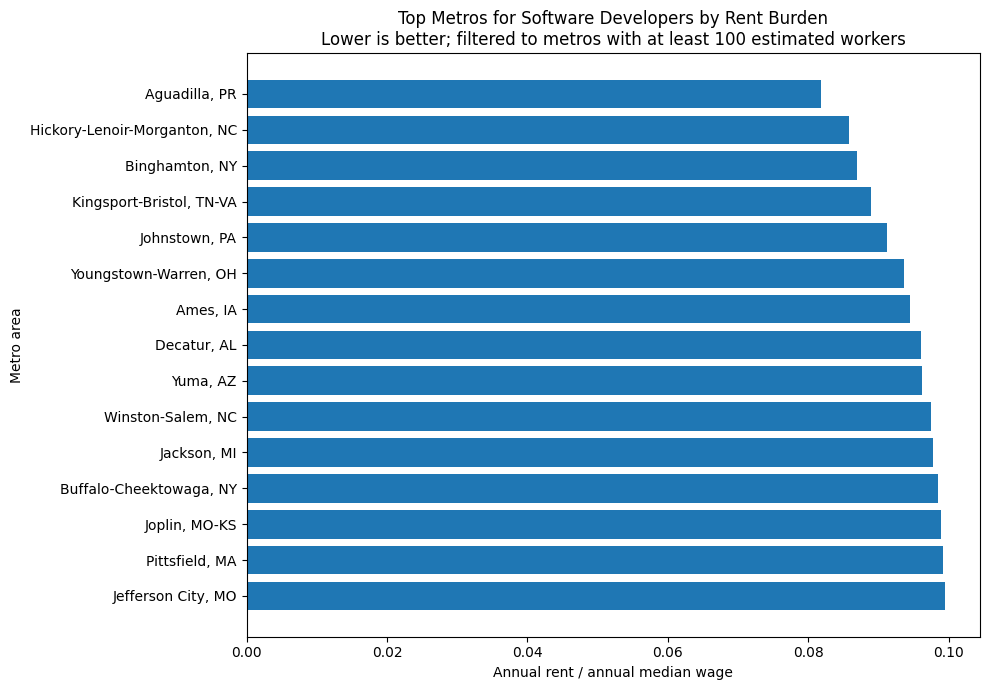

In [20]:
MIN_OCC_EMP = 100

selected_occ_base = (
    eda
    .filter(pl.col("occ_title") == selected_occ)
    .filter(pl.col(ratio_col).is_not_null())
)

selected_occ_filtered = selected_occ_base.filter(
    pl.col("tot_emp").is_not_null() & (pl.col("tot_emp") >= MIN_OCC_EMP)
)

if selected_occ_filtered.height >= 15:
    occ_rank_source = selected_occ_filtered
    rank_note = f"filtered to metros with at least {MIN_OCC_EMP:,} estimated workers"
else:
    occ_rank_source = selected_occ_base
    rank_note = "unfiltered because too few metros passed the employment filter"

occ_df = (
    occ_rank_source
    .sort(ratio_col)
    .head(15)
    .select([
        "bls_msa_name",
        wage_col,
        "annual_rent",
        ratio_col,
        "tot_emp",
        "loc_quotient",
    ])
    .to_pandas()
)

display(occ_df)

plt.figure(figsize=(10, 7))
plt.barh(occ_df["bls_msa_name"], occ_df[ratio_col])
plt.title(f"Top Metros for {selected_occ} by Rent Burden\nLower is better; {rank_note}")
plt.xlabel("Annual rent / annual median wage")
plt.ylabel("Metro area")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(FIG_DIR / "04_selected_occupation_top_metros_rent_burden.png", dpi=150)
plt.show()

### 9.6 Location Quotient vs. Wage for Selected Occupation

,bls_msa_name,loc_quotient,wage_annual_median,tot_emp,rent_to_median_wage_ratio
0,"Abilene, TX",0.33,102870.0,260.0,0.133100
1,"Aguadilla, PR",0.23,77370.0,120.0,0.081892
2,"Akron, OH",0.67,101110.0,2290.0,0.122599
3,"Albany, GA",0.28,101670.0,180.0,0.112127
4,"Albany, OR",0.21,120800.0,100.0,0.131126


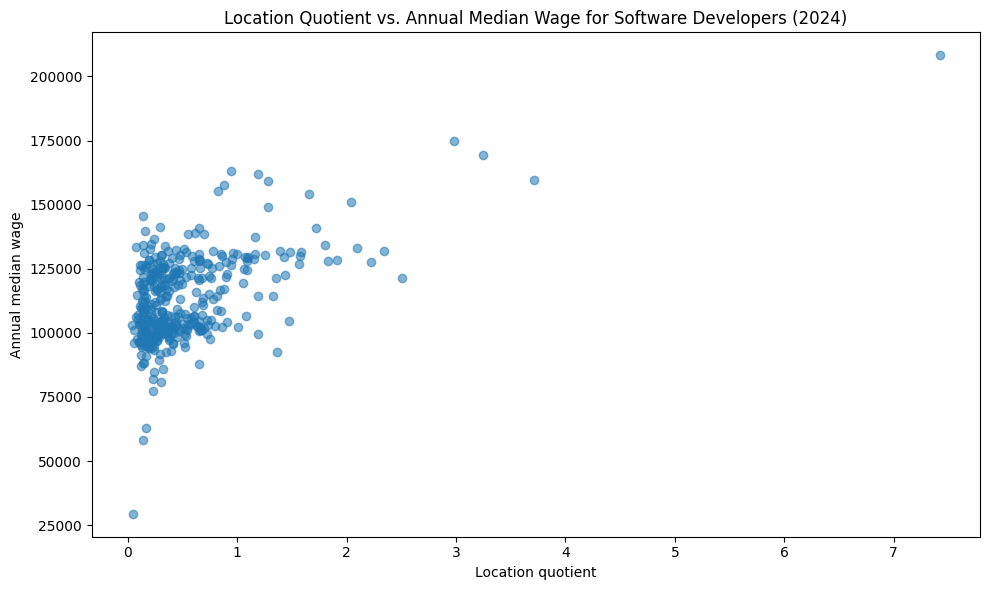

In [23]:
lq_df = (
    eda
    .filter(pl.col("occ_title") == selected_occ)
    .filter(pl.col("loc_quotient").is_not_null())
    .filter(pl.col(wage_col).is_not_null())
    .select([
        "bls_msa_name",
        "loc_quotient",
        wage_col,
        "tot_emp",
        ratio_col,
    ])
    .to_pandas()
)

display(lq_df.head())

plt.figure(figsize=(10, 6))
plt.scatter(lq_df["loc_quotient"], lq_df[wage_col], alpha=0.55)
plt.title(f"Location Quotient vs. Annual Median Wage for {selected_occ} ({EDA_YEAR})")
plt.xlabel("Location quotient")
plt.ylabel("Annual median wage")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_selected_occupation_lq_vs_wage.png", dpi=150)
plt.show()

### 9.7 Rent-Burden Distribution for High-Employment Occupations

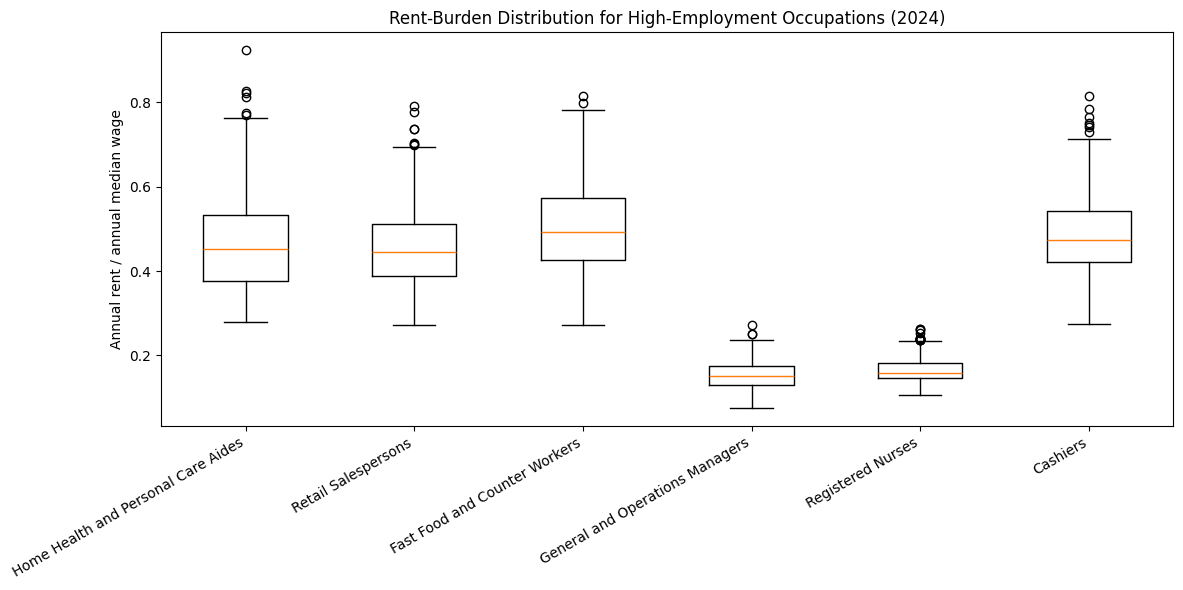

In [24]:
top_occ = (
    eda
    .filter(pl.col("tot_emp").is_not_null())
    .group_by("occ_title")
    .agg(pl.sum("tot_emp").alias("total_emp"))
    .sort("total_emp", descending=True)
    .head(6)
    .select("occ_title")
    .to_series()
    .to_list()
)

box_df = (
    eda
    .filter(pl.col("occ_title").is_in(top_occ))
    .filter(pl.col(ratio_col).is_not_null())
    .select(["occ_title", ratio_col])
    .to_pandas()
)

grouped_values = [
    box_df.loc[box_df["occ_title"] == occ, ratio_col].values
    for occ in top_occ
]

plt.figure(figsize=(12, 6))
plt.boxplot(grouped_values, tick_labels=top_occ, vert=True)
plt.title(f"Rent-Burden Distribution for High-Employment Occupations ({EDA_YEAR})")
plt.ylabel("Annual rent / annual median wage")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_rent_burden_boxplot_top_occupations.png", dpi=150)
plt.show()

### 9.8 Selected Occupation Rent-Burden Trend, 2020-2024

,year,bls_msa_name,rent_to_median_wage_ratio
0,2021,"Dallas-Fort Worth-Arlington, TX",0.126148
1,2022,"Dallas-Fort Worth-Arlington, TX",0.137475
2,2023,"Dallas-Fort Worth-Arlington, TX",0.139841
3,2024,"Dallas-Fort Worth-Arlington, TX",0.147296
4,2024,"New York-Newark-Jersey City, NY-NJ",0.135581
5,2024,"San Francisco-Oakland-Fremont, CA",0.169733
6,2021,"San Jose-Sunnyvale-Santa Clara, CA",0.182585
7,2022,"San Jose-Sunnyvale-Santa Clara, CA",0.167568
8,2023,"San Jose-Sunnyvale-Santa Clara, CA",0.168398
9,2024,"San Jose-Sunnyvale-Santa Clara, CA",0.163634


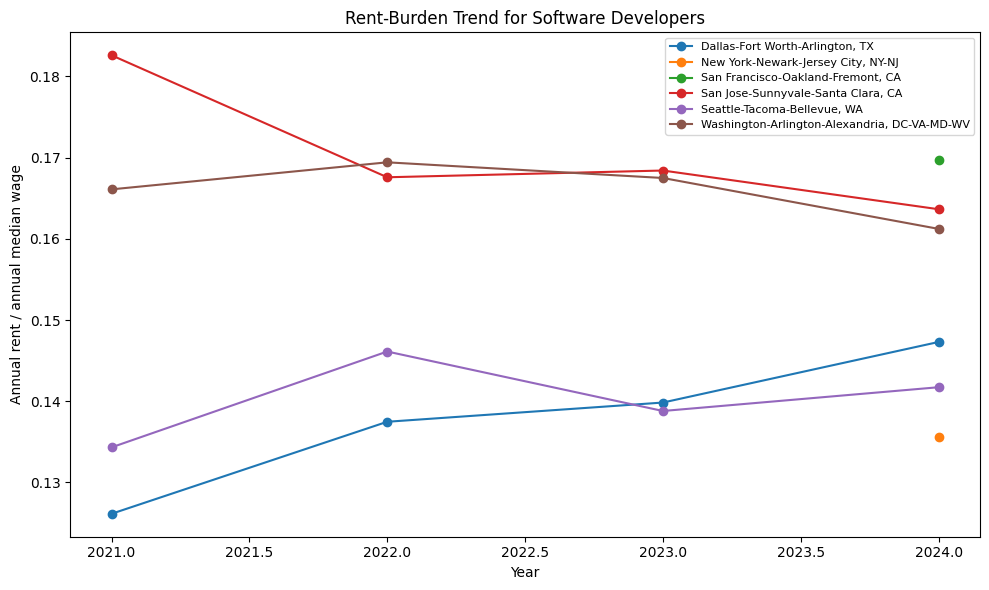

In [25]:
trend_base = (
    df_all
    .filter(pl.col("occ_title") == selected_occ)
    .filter(pl.col(ratio_col).is_not_null())
    .filter(pl.col("tot_emp").is_not_null())
)

top_trend_metros = (
    trend_base
    .filter(pl.col("year") == EDA_YEAR)
    .sort("tot_emp", descending=True)
    .head(6)
    .select("bls_msa_name")
    .to_series()
    .to_list()
)

trend_pd = (
    trend_base
    .filter(pl.col("bls_msa_name").is_in(top_trend_metros))
    .select(["year", "bls_msa_name", ratio_col])
    .sort(["bls_msa_name", "year"])
    .to_pandas()
)

display(trend_pd.head(20))

plt.figure(figsize=(10, 6))

for metro_name, group in trend_pd.groupby("bls_msa_name"):
    plt.plot(group["year"], group[ratio_col], marker="o", label=metro_name)

plt.title(f"Rent-Burden Trend for {selected_occ}")
plt.xlabel("Year")
plt.ylabel("Annual rent / annual median wage")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "07_selected_occupation_rent_burden_trend.png", dpi=150)
plt.show()

## 10. Final Processed Dataset Output

In [26]:
final_summary = {
    "final_dataset_csv": str(FINAL_DATASET_CSV_PATH),
    "final_dataset_parquet": str(FINAL_DATASET_PARQUET_PATH),
    "yearly_build_summary_csv": str(YEARLY_BUILD_SUMMARY_CSV_PATH),
    "processed_dir": str(PROCESSED_DIR),
    "interim_dir": str(INTERIM_DIR),
    "figures_dir": str(FIG_DIR),
}

display(pd.DataFrame(final_summary.items(), columns=["artifact", "path"]))

final_dataset = read_final_dataset()

print_shape("Final dataset", final_dataset)

print("Final 2020-2024 table preview:")
display(final_dataset.head(25).to_pandas())

print("Final row-count summary:")
display(
    final_dataset
    .group_by("year")
    .agg([
        pl.len().alias("n_rows"),
        pl.col("cbsa_code").n_unique().alias("n_metros"),
        pl.col("occ_code").n_unique().alias("n_occupations"),
        (
            pl.col("rent_to_median_wage_ratio")
            .is_not_null()
            .cast(pl.Float64)
            .mean()
            * 100
        )
        .round(2)
        .alias("pct_with_valid_rent_burden"),
    ])
    .sort("year")
    .to_pandas()
)

,artifact,path
0,final_dataset_csv,/Users/omarelnesr/Desktop/Classes/CIS 2450/Fin...
1,final_dataset_parquet,/Users/omarelnesr/Desktop/Classes/CIS 2450/Fin...
2,yearly_build_summary_csv,/Users/omarelnesr/Desktop/Classes/CIS 2450/Fin...
3,processed_dir,/Users/omarelnesr/Desktop/Classes/CIS 2450/Fin...
4,interim_dir,/Users/omarelnesr/Desktop/Classes/CIS 2450/Fin...
5,figures_dir,/Users/omarelnesr/Desktop/Classes/CIS 2450/Fin...


Final dataset: 689,932 rows × 38 cols
Final 2020-2024 table preview:


,year,cbsa_code,bls_msa_name,acs_area_name,prim_state,occ_code,occ_title,o_group,tot_emp,emp_prse,...,annual_mean_wage_to_metro_income_ratio,annual_median_wage_to_metro_income_ratio,log_tot_emp,low_employment_flag,high_lq_flag,has_valid_mean_affordability,has_valid_median_affordability,area_title,rent_to_annual_mean_wage_ratio,rent_to_annual_median_wage_ratio
0,2020,10180,"Abilene, TX","Abilene, TX Metro Area",TX,11-1021,General and Operations Managers,detailed,1320.0,7.4,...,1.531072,1.249613,7.185387,False,False,True,True,"Abilene, TX",0.129730,0.158950
1,2020,10180,"Abilene, TX","Abilene, TX Metro Area",TX,11-2022,Sales Managers,detailed,90.0,18.5,...,2.206099,1.986984,4.499810,True,False,True,True,"Abilene, TX",0.090035,0.099963
2,2020,10180,"Abilene, TX","Abilene, TX Metro Area",TX,11-2030,Public Relations and Fundraising Managers,detailed,40.0,31.5,...,1.741619,1.374118,3.688879,True,False,True,True,"Abilene, TX",0.114046,0.144548
3,2020,10180,"Abilene, TX","Abilene, TX Metro Area",TX,11-3010,Administrative Services and Facilities Managers,detailed,140.0,12.3,...,1.432816,1.329274,4.941642,False,False,True,True,"Abilene, TX",0.138626,0.149424
4,2020,10180,"Abilene, TX","Abilene, TX Metro Area",TX,11-3021,Computer and Information Systems Managers,detailed,70.0,30.2,...,2.242923,2.133912,4.248495,True,False,True,True,"Abilene, TX",0.088557,0.093080
5,2020,10180,"Abilene, TX","Abilene, TX Metro Area",TX,11-3031,Financial Managers,detailed,120.0,8.8,...,2.179849,1.751463,4.787492,False,False,True,True,"Abilene, TX",0.091119,0.113405
6,2020,10180,"Abilene, TX","Abilene, TX Metro Area",TX,11-3051,Industrial Production Managers,detailed,50.0,22.3,...,2.072297,1.798859,3.912023,True,False,True,True,"Abilene, TX",0.095848,0.110418
7,2020,10180,"Abilene, TX","Abilene, TX Metro Area",TX,11-3071,"Transportation, Storage, and Distribution Mana...",detailed,60.0,18.6,...,1.550030,1.502634,4.094345,True,False,True,True,"Abilene, TX",0.128143,0.132185
8,2020,10180,"Abilene, TX","Abilene, TX Metro Area",TX,11-3121,Human Resources Managers,detailed,60.0,45.1,...,1.189274,0.887580,4.094345,True,False,True,True,"Abilene, TX",0.167014,0.223783
9,2020,10180,"Abilene, TX","Abilene, TX Metro Area",TX,11-9021,Construction Managers,detailed,160.0,14.2,...,1.402738,1.164300,5.075174,False,False,True,True,"Abilene, TX",0.141598,0.170597


Final row-count summary:


,year,n_rows,n_metros,n_occupations,pct_with_valid_rent_burden
0,2020,131010,396,785,91.26
1,2021,138116,396,826,92.24
2,2022,139124,396,828,92.45
3,2023,140518,396,826,91.29
4,2024,141164,393,823,98.33


## 11. Modeling Notebook Handoff

This notebook ends after data wrangling, validation, EDA, and final dataset export.

The separate modeling notebook should begin with:

```python
import polars as pl

df = pl.read_csv(
    "data/processed/career_city_fit_2020_2024.csv",
    infer_schema_length=5000,
)

df = df.with_columns([
    pl.col("cbsa_code").cast(pl.Utf8).str.zfill(5),
    pl.col("occ_code").cast(pl.Utf8),
])